# Predicción de la necesidad de receta médica en medicamentos

**Curso:** Metodología para Data Science  
**Grupo:** 4  

Fases cubiertas en este notebook:
1. Comprensión del negocio  
2. Comprensión de los datos  
3. Preparación de los datos (dataset final listo para modelar)
4. Modelado  
5. Evaluación  
6. Implementación

In [21]:
# ======================================
# Paso 1: Importación de librerías
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# 1. Comprensión del negocio

En esta sección se define el problema de negocio, la pregunta que responde el proyecto
y el impacto esperado.

## 1.1 Planteamiento del problema
El crecimiento del comercio digital de medicamentos ha incrementado el riesgo de venta en línea de fármacos que requieren receta médica sin la debida supervisión. Esto genera problemas regulatorios, de seguridad del paciente y de reputación para farmacias digitales, que manejan catálogos con miles de productos.

El proyecto busca apoyar a estas farmacias mediante un modelo capaz de **predecir automáticamente si un medicamento requiere receta médica**, usando atributos como precio final, fabricante, país de origen, enfermedad asociada y principio activo.

## 1.2 Pregunta de negocio
> A partir de la información estructurada del catálogo de medicamentos,
> ¿podemos clasificar si un producto requiere receta médica o no?

## 1.3 Objetivo de negocio y KPIs
- Reducir errores de categorización de medicamentos que requieren receta.
- Mejorar el cumplimiento normativo en farmacias digitales.

KPIs técnicos (para fases posteriores):
- Accuracy objetivo ≥ 75 %
- F1-score ≥ 0.70


# 2. Comprensión de los datos

## 2.1 Carga del dataset
Dataset: `medicines.csv` (Medicines Dataset – NetMeds, Kaggle).
Cada fila representa un medicamento con información de:
- `med_name`: nombre comercial
- `generic_name`: principio activo
- `disease_name`: enfermedad asociada
- `price`, `final_price`: precios antes y después de descuento
- `drug_manufacturer`, `drug_manufacturer_origin`
- `drug_variant`: presentación
- `prescription_required`: indica si requiere receta (variable objetivo)

In [22]:
# ======================================
# Paso 2: Cargar el dataset
# ======================================
df = pd.read_csv("medicines.csv", low_memory=False)

print("Dimensiones iniciales del dataset:", df.shape)
display(df.head())

Dimensiones iniciales del dataset: (23939, 13)


,disease_name,disease_url,med_name,med_url,final_price,price,prescription_required,drug_varient,drug_manufacturer,drug_manufacturer_origin,drug_content,generic_name,img_urls
0,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Atrest 25mg Tablet 10'S,https://www.netmeds.com/prescriptions/atrest-25mg-tablet-10-s,₹335.68,MRP ₹381.46 Save 12 %,Rx required,*10 Tablet(s) in a Strip,* Mkt: Centaur Pharmaceuticals Pvt Ltd,* Country of Origin: India,INTRODUCTION ABOUT ATREST 25MG TABLETATREST 25MG TABLET contains Tetrabenazine which belongs to the group of medicin...,Generic Name Tetrabenazine 25 mg,"https://www.netmeds.com/images/product-v1/600x600/847249/atrest_25mg_tablet_10_s_0.jpg, https://www.netmeds.com/imag..."
1,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Capnea Injection 1ml,https://www.netmeds.com/prescriptions/capnea-injection-1ml,₹246.88,MRP ₹280.55 Save 12 %,Rx required,NaN,* Mkt: Cipla Ltd,* Country of Origin: India,INTRODUCTION ABOUT CAPNEA INJECTIONCAPNEA INJECTION contains Caffeine which belongs to the group of medicines called...,Generic Name Caffeine 20 mg,https://www.netmeds.com/images/product-v1/600x600/349693/capnea_injection_1ml_0.jpg
2,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Capnea Oral Solution 1ml,https://www.netmeds.com/prescriptions/capnea-solution-1ml,MRP ₹275.15,MRP ₹ 275.15,Rx required,NaN,* Mkt: Cipla Ltd,* Country of Origin: India,INTRODUCTION ABOUT CAPNEA SOLUTIONCAPNEA SOLUTION contains Caffeine which belongs to the group of medicines called C...,Generic Name Caffeine 20 mg,"https://www.netmeds.com/images/product-v1/600x600/349695/capnea_oral_solution_1ml_0_0.jpg, https://www.netmeds.com/i..."
3,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Cognistar 30mg Injection 1'S,https://www.netmeds.com/prescriptions/cognistar-30mg-injection,₹706.02,MRP ₹802.30 Save 12 %,Rx required,NaN,* Mkt: Lupin Ltd,* Country of Origin: India,INTRODUCTIONCOGNISTAR 30MG contains Cerebroprotein Hydrolysate which belongs to the group of medicines called Neurot...,Generic Name Cerebroprotein Hydrolysate 30 mg,"https://www.netmeds.com/images/product-v1/600x600/370785/cognistar_30mg_injection_1s_0_0.jpg, https://www.netmeds.co..."
4,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Cognistar 60mg Injection 1's,https://www.netmeds.com/prescriptions/cognistar-60mg-injection,₹1314.90,MRP ₹1494.20 Save 12 %,Rx required,NaN,* Mkt: Lupin Ltd,* Country of Origin: India,INTRODUCTION ABOUT COGNISTAR 60MG INJECTIONCOGNISTAR 60MG INJECTION contains Cerebroprotein Hydrolysate which belong...,Generic Name Cerebroprotein Hydrolysate 60 mg,https://www.netmeds.com/images/product-v1/600x600/370786/cognistar_60mg_injection_0.jpg


In [23]:
# ======================================
# Paso 3: Información general de los datos
# ======================================
print("\n=== Información general del DataFrame ===")
df.info()

# Resumen de nulos
print("\n=== Valores nulos por columna (top 10) ===")
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)
print(missing.head(10))


=== Información general del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23939 entries, 0 to 23938
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   disease_name              23939 non-null  object
 1   disease_url               23939 non-null  object
 2   med_name                  23939 non-null  object
 3   med_url                   23939 non-null  object
 4   final_price               23939 non-null  object
 5   price                     23181 non-null  object
 6   prescription_required     21109 non-null  object
 7   drug_varient              15199 non-null  object
 8   drug_manufacturer         23760 non-null  object
 9   drug_manufacturer_origin  23760 non-null  object
 10  drug_content              23756 non-null  object
 11  generic_name              23569 non-null  object
 12  img_urls                  23760 non-null  object
dtypes: object(13)
memory usage: 2.4+ 

## 2.2 Exploración inicial de la variable objetivo
Revisamos valores reales y normalizados de `prescription_required`.


Valores únicos originales en 'prescription_required':
prescription_required
Rx required    21109
NaN             2830
Name: count, dtype: int64

Valores normalizados:
prescription_required
rx required    21109
nan             2830
Name: count, dtype: int64

Distribución absoluta:
prescription_required
Requiere receta                  21109
No requiere / Sin información     2830
Name: count, dtype: int64

Distribución relativa (%):
prescription_required
Requiere receta                  88.18
No requiere / Sin información    11.82
Name: proportion, dtype: float64


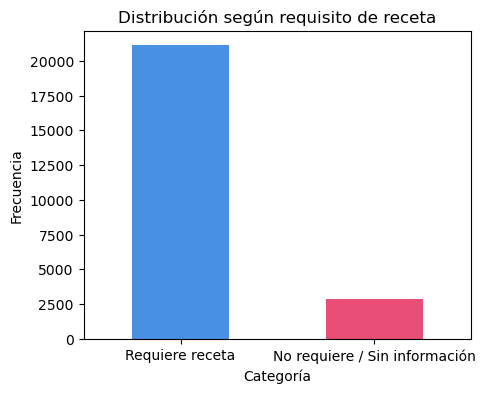

In [24]:
# ======================================
# Paso 4: Exploración de la variable objetivo (sin transformar)
# ======================================
target_col = "prescription_required"

print("\nValores únicos originales en 'prescription_required':")
print(df[target_col].value_counts(dropna=False))

# Normalización
target_raw = (
    df[target_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

print("\nValores normalizados:")
print(target_raw.value_counts(dropna=False).head(20))

# Agrupación para EDA
y_label = target_raw.apply(
    lambda v: "Requiere receta"
    if v in ["rx required", "rx_required", "rx  required"]
    else "No requiere / Sin información"
)

print("\nDistribución absoluta:")
print(y_label.value_counts())

print("\nDistribución relativa (%):")
print((y_label.value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5,4))
y_label.value_counts().plot(kind="bar", title="Distribución según requisito de receta", color=["#4a90e2", "#e94e77"])
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

## 2.3 Limpieza temprana de `price` y `final_price`
Convertimos a formato numérico para evitar errores en gráficos posteriores.

In [25]:
# ======================================
# Paso 5: Limpieza numérica básica
# ======================================
for col in ["price", "final_price"]:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace(r"[^\d\.\-]", "", regex=True)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nEstadísticos descriptivos de precios:")
display(df[["price", "final_price"]].describe())


Estadísticos descriptivos de precios:


,price,final_price
count,20926.000000,23760.000000
mean,401.763396,375.535661
std,2636.848414,2301.183179
min,1.901000,1.710000
25%,91.601200,87.120000
50%,161.701200,152.605000
75%,287.790900,275.000000
max,151670.001000,136503.000000


## 2.4 Estadísticos descriptivos y detección de outliers

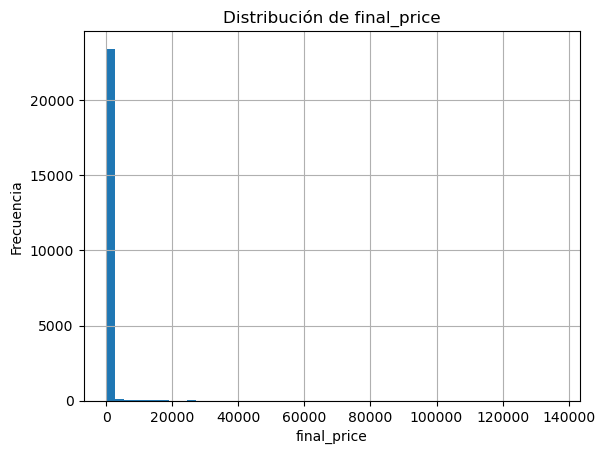

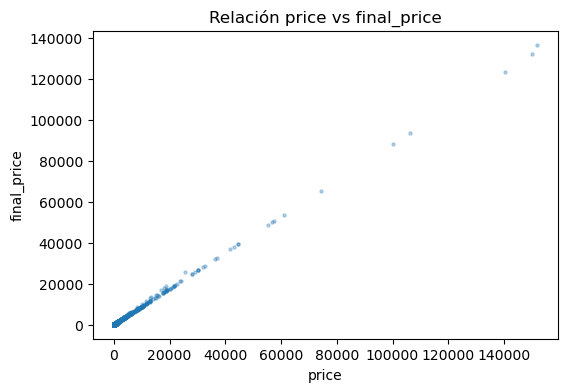

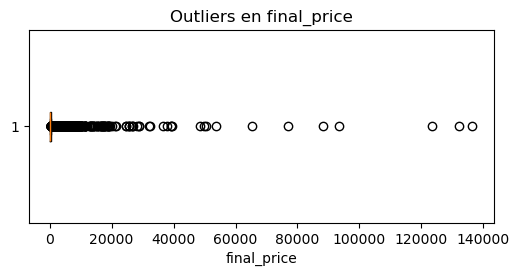

In [26]:
# ======================================
# Paso 6: Visualizaciones numéricas
# ======================================

# Histograma final_price
df["final_price"].dropna().hist(bins=50)
plt.title("Distribución de final_price")
plt.xlabel("final_price")
plt.ylabel("Frecuencia")
plt.show()

# Scatter price vs final_price
mask = df["price"].notna() & df["final_price"].notna()
if mask.any():
    plt.figure(figsize=(6,4))
    plt.scatter(df.loc[mask,"price"], df.loc[mask,"final_price"], alpha=0.3, s=5)
    plt.title("Relación price vs final_price")
    plt.xlabel("price")
    plt.ylabel("final_price")
    plt.show()

# Boxplot simple (detección técnica de outliers)
plt.figure(figsize=(6,2.5))
plt.boxplot(df["final_price"].dropna(), vert=False, showfliers=True)
plt.title("Outliers en final_price")
plt.xlabel("final_price")
plt.show()

## 2.5 Gráficos exploratorios adicionales (EDA)

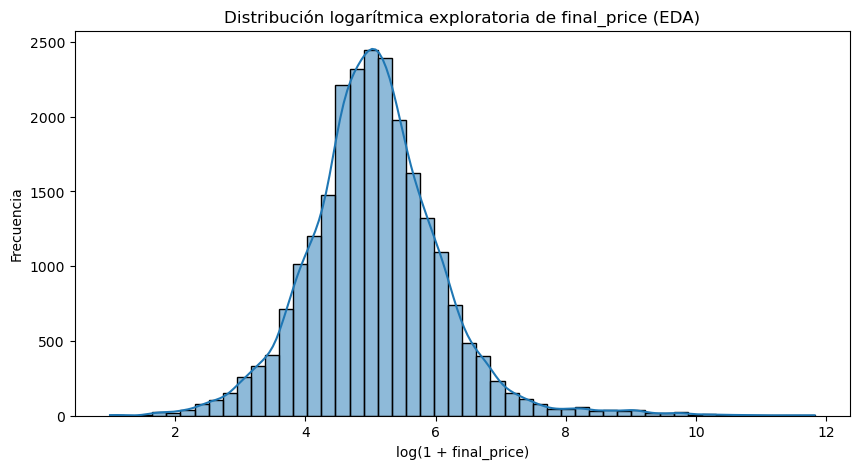

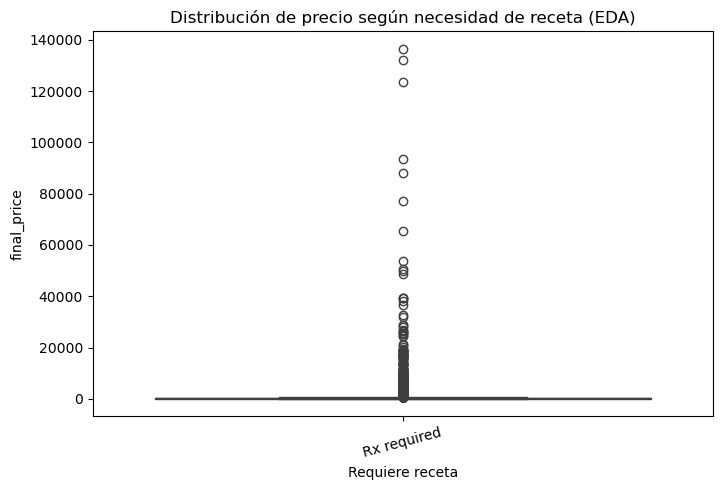

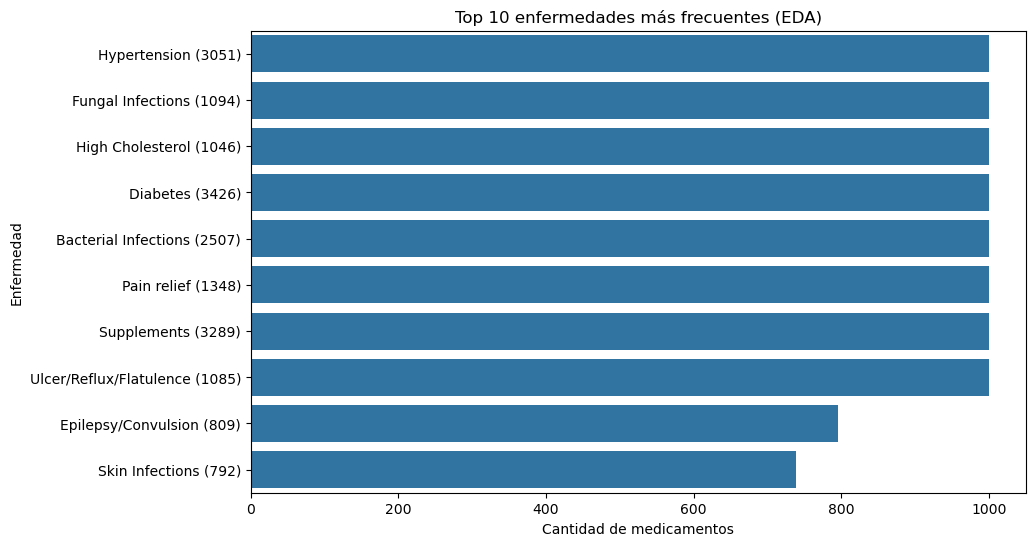

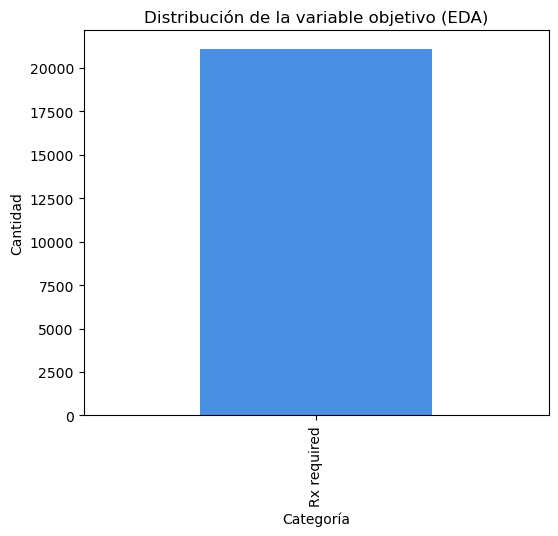

prescription_required
Rx required    100.0
Name: proportion, dtype: float64


In [27]:
# ======================================
# Paso 7.1: Distribución logarítmica exploratoria de final_price (EDA)
# ======================================
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df["final_price"].dropna()), bins=50, kde=True)
plt.title("Distribución logarítmica exploratoria de final_price (EDA)")
plt.xlabel("log(1 + final_price)")
plt.ylabel("Frecuencia")
plt.show()


# ======================================
# Paso 7.2: Boxplot final_price por categoría (EDA)
# ======================================
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df.dropna(subset=["final_price", "prescription_required"]),
    x="prescription_required",
    y="final_price"
)
plt.title("Distribución de precio según necesidad de receta (EDA)")
plt.xlabel("Requiere receta")
plt.ylabel("final_price")
plt.xticks(rotation=15)
plt.show()


# ======================================
# Paso 7.3: Top 10 enfermedades más frecuentes (EDA)
# ======================================
top_diseases = df["disease_name"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_diseases.values, y=top_diseases.index)
plt.title("Top 10 enfermedades más frecuentes (EDA)")
plt.xlabel("Cantidad de medicamentos")
plt.ylabel("Enfermedad")
plt.show()


# ======================================
# Paso 7.4: Distribución de prescription_required (EDA)
# ======================================
plt.figure(figsize=(6,5))
df["prescription_required"].value_counts().plot(kind="bar", color=["#4a90e2","#e94e77"])
plt.title("Distribución de la variable objetivo (EDA)")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.show()

print(df["prescription_required"].value_counts(normalize=True)*100)

 ## 2.6 Calidad de datos: nulos y duplicados

In [28]:
# ======================================
# Paso 7.5: Auditoría rápida de nulos y duplicados
# ======================================
missing = (
    df.isna()
    .sum()
    .to_frame("Nulos")
    .assign(Porcentaje=lambda x: (x["Nulos"]/len(df)*100).round(2))
    .sort_values("Nulos", ascending=False)
)
display(missing.head(10))

print("\nDuplicados:", df.duplicated().sum())

,Nulos,Porcentaje
drug_varient,8740,36.51
price,3013,12.59
prescription_required,2830,11.82
generic_name,370,1.55
drug_content,183,0.76
final_price,179,0.75
drug_manufacturer,179,0.75
drug_manufacturer_origin,179,0.75
img_urls,179,0.75
med_url,0,0.00



Duplicados: 0


## 3. Preparación de los datos
Objetivo: dejar un **conjunto de datos final** listo para la fase de Modelado, que incluya:
- Variables imputadas y sin nulos en columnas críticas.
- Outliers tratados mediante transformación.
- Selección de columnas relevantes.
- Codificación numérica de las variables categóricas.

## 3.1 Imputación de valores faltantes
Estrategia:
- Variables categóricas: imputar nulos con la etiqueta `"Sin información"`.
- Variables críticas (`price`, `prescription_required`): eliminar filas con nulos, ya que impiden definir la etiqueta y el precio de referencia.


=== Nulos ANTES ===
drug_varient                8740
price                       3013
prescription_required       2830
generic_name                 370
drug_content                 183
final_price                  179
drug_manufacturer            179
drug_manufacturer_origin     179
img_urls                     179
med_url                        0
dtype: int64


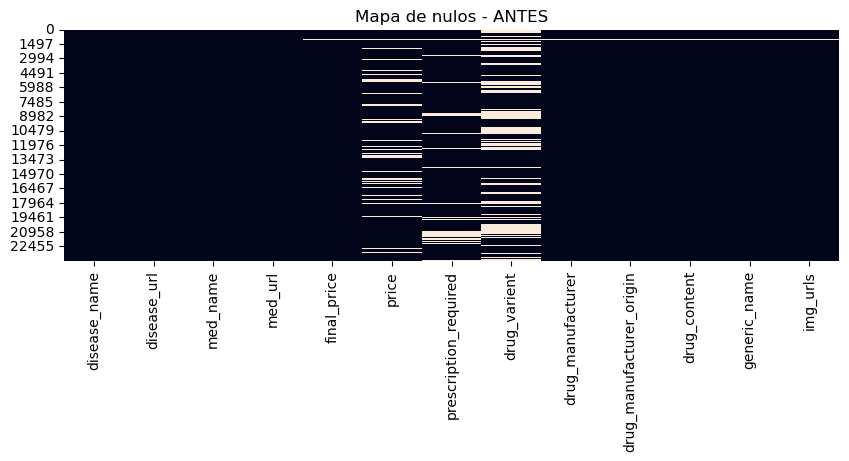


=== Nulos DESPUÉS ===
disease_name                0
disease_url                 0
med_name                    0
med_url                     0
final_price                 0
price                       0
prescription_required       0
drug_varient                0
drug_manufacturer           0
drug_manufacturer_origin    0
dtype: int64


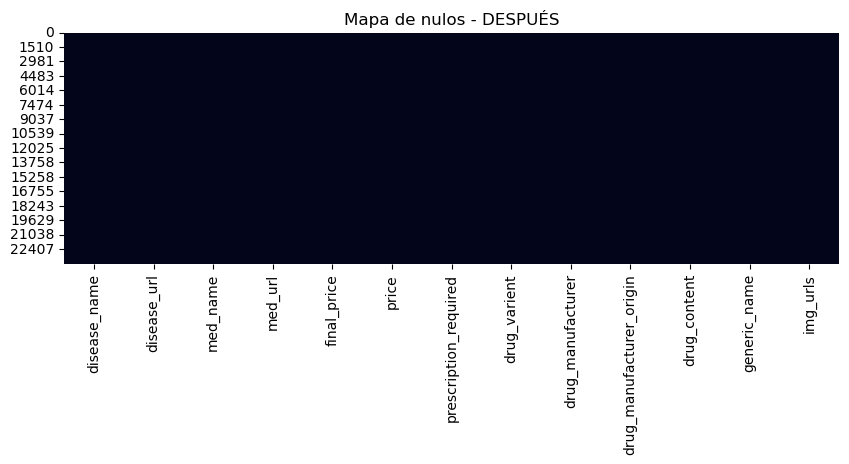


Dimensiones tras limpieza: (20926, 13)


In [29]:
# ======================================
# Paso 8: Imputación de nulos + limpieza crítica
# ======================================

print("=== Nulos ANTES ===")
print(df.isna().sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,3))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de nulos - ANTES")
plt.show()

# Imputar categóricas
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna("Sin información")

# Eliminar registros incompletos en variables críticas
critical_cols = ["price", "prescription_required"]
df = df.dropna(subset=critical_cols)

print("\n=== Nulos DESPUÉS ===")
print(df.isna().sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,3))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de nulos - DESPUÉS")
plt.show()

print("\nDimensiones tras limpieza:", df.shape)

## 3.2 Transformación logarítmica de final_price
En lugar de eliminar outliers de precio (que podrían ser casos reales), aplicamos `log1p` para:
- Reducir la asimetría.
- Disminuir el impacto de valores extremos en el modelo.

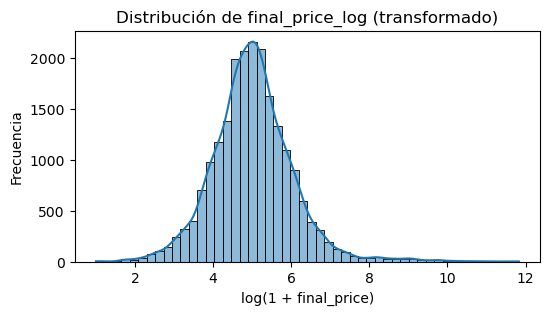

In [30]:
# ======================================
# Paso 9: Crear final_price_log (transformación técnica)
# ======================================
df["final_price_log"] = np.log1p(df["final_price"])

plt.figure(figsize=(6,3))
sns.histplot(df["final_price_log"].dropna(), bins=50, kde=True)
plt.title("Distribución de final_price_log (transformado)")
plt.xlabel("log(1 + final_price)")
plt.ylabel("Frecuencia")
plt.show()

## 3.3 Construcción del target binario `y`
Se define la clasificación binaria:
- `y = 1`: medicamento que requiere receta.
- `y = 0`: otros casos (no requiere receta / sin información).
Usamos la versión normalizada de `prescription_required` para evitar problemas por mayúsculas o espacios.

In [31]:
# ======================================
# Paso 10: Construcción de variable objetivo
# ======================================
target_raw = (
    df[target_col]
    .astype(str)
    .str.lower()
    .str.strip()
)

y = target_raw.apply(
    lambda v: 1 if v in ["rx required","rx_required","rx  required"] else 0
)

print("Distribución de y:")
print(y.value_counts())
print((y.value_counts(normalize=True)*100).round(2))

Distribución de y:
prescription_required
1    18421
0     2505
Name: count, dtype: int64
prescription_required
1    88.03
0    11.97
Name: proportion, dtype: float64


## 3.4 Selección de features
De acuerdo con el análisis exploratorio y el informe del proyecto:
- Se conserva **solo `final_price` (y su versión logarítmica)** para evitar redundancia con `price`.
- Se incluyen variables categóricas relevantes:
   - `drug_varient`
   - `drug_manufacturer`
   - `drug_manufacturer_origin`
   - `generic_name`
   - `disease_name`
El campo de texto libre `drug_content` se conserva en el DataFrame original para futuros análisis NLP, pero **no** se incluye en este primer dataset estructurado de modelado.

In [32]:
# ======================================
# Paso 11: Selección de columnas relevantes
# ======================================
feature_cols = [
    "final_price_log",
    "drug_varient",
    "drug_manufacturer",
    "drug_manufacturer_origin",
    "generic_name",
    "disease_name",
]

feature_cols = [c for c in feature_cols if c in df.columns]

print("Features seleccionadas:")
print(feature_cols)

X = df[feature_cols]

Features seleccionadas:
['final_price_log', 'drug_varient', 'drug_manufacturer', 'drug_manufacturer_origin', 'generic_name', 'disease_name']


## 3.5 Codificación con One-Hot Encoding

In [33]:
# ======================================
# Paso 12: Preprocesador para variables categóricas
# ======================================
numeric_features = ["final_price_log"]
categorical_features = [c for c in feature_cols if c != "final_price_log"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

print("\nPreprocesador configurado.")


Preprocesador configurado.


In [34]:
# ======================================
# Paso 13: Transformación final de X
# ======================================
X_prepared = preprocessor.fit_transform(X)

print("Dimensiones X original:", X.shape)
print("Dimensiones X_prepared:", X_prepared.shape)

Dimensiones X original: (20926, 6)
Dimensiones X_prepared: (20926, 7119)


## 3.6 Guardar dataset limpio

In [35]:
# ======================================
# Paso 14: Guardar medicines_clean.csv
# ======================================
df_clean = df.copy()
df_clean["target_binary"] = y
df_clean.to_csv("medicines_clean.csv", index=False)

print("Archivo 'medicines_clean.csv' guardado correctamente.")
print("Fase 3 completada. Listo para Fase 4 — Modelado.")

Archivo 'medicines_clean.csv' guardado correctamente.
Fase 3 completada. Listo para Fase 4 — Modelado.


## 4. Modelado

En esta fase se entrenan los modelos definidos en nuestra estrategia metodológica:
1. **Regresión Logística** – modelo base explicativo.  
2. **Random Forest Classifier** – modelo predictivo principal.
Siguiendo el documento entregable del grupo:
- Se usa **Train/Test Split (80/20)**
- Se aplica **Validación Cruzada K-Fold = 5**
- Métricas: **Accuracy, Precision, Recall, F1-score**

El modelo final se elige según **F1-score**, dando prioridad al Recall por el impacto regulatorio.

In [36]:
# ======================================
# Paso 15: Importación de librerías Fase 4
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)


In [37]:
# ======================================
# Paso 16: Cargar dataset limpio de la Fase 3
# ======================================

df = pd.read_csv("medicines_clean.csv")

print("Dimensiones dataset limpio:", df.shape)
df.head()

Dimensiones dataset limpio: (20926, 15)


,disease_name,disease_url,med_name,med_url,final_price,price,prescription_required,drug_varient,drug_manufacturer,drug_manufacturer_origin,drug_content,generic_name,img_urls,final_price_log,target_binary
0,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Atrest 25mg Tablet 10'S,https://www.netmeds.com/prescriptions/atrest-25mg-tablet-10-s,335.68,381.4612,Rx required,*10 Tablet(s) in a Strip,* Mkt: Centaur Pharmaceuticals Pvt Ltd,* Country of Origin: India,INTRODUCTION ABOUT ATREST 25MG TABLETATREST 25MG TABLET contains Tetrabenazine which belongs to the group of medicin...,Generic Name Tetrabenazine 25 mg,"https://www.netmeds.com/images/product-v1/600x600/847249/atrest_25mg_tablet_10_s_0.jpg, https://www.netmeds.com/imag...",5.819133,1
1,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Capnea Injection 1ml,https://www.netmeds.com/prescriptions/capnea-injection-1ml,246.88,280.5512,Rx required,Sin información,* Mkt: Cipla Ltd,* Country of Origin: India,INTRODUCTION ABOUT CAPNEA INJECTIONCAPNEA INJECTION contains Caffeine which belongs to the group of medicines called...,Generic Name Caffeine 20 mg,https://www.netmeds.com/images/product-v1/600x600/349693/capnea_injection_1ml_0.jpg,5.512945,1
2,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Capnea Oral Solution 1ml,https://www.netmeds.com/prescriptions/capnea-solution-1ml,275.15,275.1500,Rx required,Sin información,* Mkt: Cipla Ltd,* Country of Origin: India,INTRODUCTION ABOUT CAPNEA SOLUTIONCAPNEA SOLUTION contains Caffeine which belongs to the group of medicines called C...,Generic Name Caffeine 20 mg,"https://www.netmeds.com/images/product-v1/600x600/349695/capnea_oral_solution_1ml_0_0.jpg, https://www.netmeds.com/i...",5.620944,1
3,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Cognistar 30mg Injection 1'S,https://www.netmeds.com/prescriptions/cognistar-30mg-injection,706.02,802.3012,Rx required,Sin información,* Mkt: Lupin Ltd,* Country of Origin: India,INTRODUCTIONCOGNISTAR 30MG contains Cerebroprotein Hydrolysate which belongs to the group of medicines called Neurot...,Generic Name Cerebroprotein Hydrolysate 30 mg,"https://www.netmeds.com/images/product-v1/600x600/370785/cognistar_30mg_injection_1s_0_0.jpg, https://www.netmeds.co...",6.561059,1
4,ADHD (7),https://www.netmeds.com/prescriptions/adhd,Cognistar 60mg Injection 1's,https://www.netmeds.com/prescriptions/cognistar-60mg-injection,1314.90,1494.2012,Rx required,Sin información,* Mkt: Lupin Ltd,* Country of Origin: India,INTRODUCTION ABOUT COGNISTAR 60MG INJECTIONCOGNISTAR 60MG INJECTION contains Cerebroprotein Hydrolysate which belong...,Generic Name Cerebroprotein Hydrolysate 60 mg,https://www.netmeds.com/images/product-v1/600x600/370786/cognistar_60mg_injection_0.jpg,7.182276,1


In [38]:
# ======================================
# Paso 17: Definir variables X e y
# ======================================

y = df["target_binary"]

feature_cols = [
    "final_price_log",
    "drug_varient",
    "drug_manufacturer",
    "drug_manufacturer_origin",
    "generic_name",
    "disease_name",
]

X_raw = df[feature_cols].copy()

numeric_features = ["final_price_log"]
categorical_features = [c for c in feature_cols if c != "final_price_log"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

# Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocesar
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (16740, 6306)
X_test : (4186, 6306)


## 4.1 Validación Cruzada (K=5)

In [39]:
# ======================================
# Paso 18: Función auxiliar para CV
# ======================================

def evaluar_cv(modelo, X, y, nombre):
    scoring = ["accuracy", "precision", "recall", "f1"]

    cv = cross_validate(
        modelo, X, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    print(f"\n======= Resultados CV — {nombre} =======")
    resultados_mean = {}

    for m in scoring:
        mean_val = cv[f"test_{m}"].mean()
        resultados_mean[m] = mean_val
        print(f"{m.capitalize():<10}: {mean_val:.4f}")

    return resultados_mean

## 4.2 Modelo 1: Regresión Logística

In [40]:
# ======================================
# Paso 19: Entrenar Regresión Logística con CV
# ======================================

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

result_log = evaluar_cv(log_reg, X_train, y_train, "Regresión Logística")


======= Resultados CV — Regresión Logística =======
Accuracy  : 0.9234
Precision : 0.9838
Recall    : 0.9282
F1        : 0.9552


## 4.3 Modelo 2: Random Forest

In [41]:
# ======================================
# Paso 20: Entrenar Random Forest con CV
# ======================================

rf_clf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

result_rf = evaluar_cv(rf_clf, X_train, y_train, "Random Forest")


======= Resultados CV — Random Forest =======
Accuracy  : 0.9433
Precision : 0.9579
Recall    : 0.9787
F1        : 0.9682


## 4.4 Comparación de modelos

In [42]:
# ======================================
# Paso 21: Tabla comparativa
# ======================================

resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [result_log["accuracy"], result_rf["accuracy"]],
    "Precision": [result_log["precision"], result_rf["precision"]],
    "Recall": [result_log["recall"], result_rf["recall"]],
    "F1-score": [result_log["f1"], result_rf["f1"]],
})

print("\n=== Comparación Final de Modelos ===")
display(resultados)


=== Comparación Final de Modelos ===


,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.923357,0.983827,0.928203,0.955197
1,Random Forest,0.943309,0.957854,0.978692,0.968154


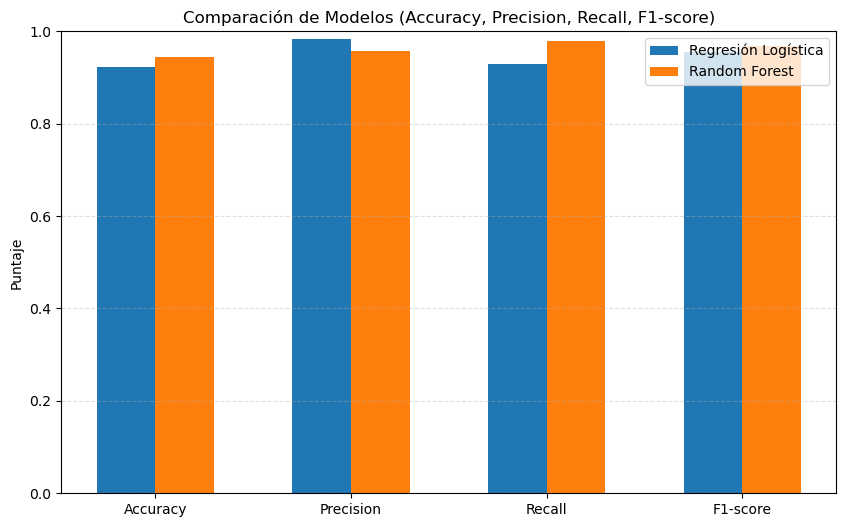

In [43]:
# ======================================
# Paso 22: Gráfico comparativo de modelos
# ======================================

metricas = ["Accuracy", "Precision", "Recall", "F1-score"]
modelos = resultados["Modelo"].tolist()

# Convertir a matriz (2 modelos x 4 métricas)
valores = resultados[metricas].values

plt.figure(figsize=(10,6))
x = np.arange(len(metricas))
ancho = 0.30

# Dibujar barras para cada modelo
for i in range(len(modelos)):
    plt.bar(x + i*ancho, valores[i], width=ancho, label=modelos[i])

plt.xticks(x + ancho/2, metricas)
plt.ylabel("Puntaje")
plt.title("Comparación de Modelos (Accuracy, Precision, Recall, F1-score)")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [44]:
# ======================================
# Paso 23: Selección automática del mejor modelo (según F1-score)
# ======================================

idx_best = resultados["F1-score"].idxmax()
mejor_nombre = resultados.loc[idx_best, "Modelo"]

print(f"\n🔥 Mejor modelo según F1-score: **{mejor_nombre}**")

# Entrenar mejor modelo en todo el X_train
mejor_modelo = rf_clf if mejor_nombre == "Random Forest" else log_reg
mejor_modelo.fit(X_train, y_train)

# Predicciones finales
y_pred = mejor_modelo.predict(X_test)
y_proba = mejor_modelo.predict_proba(X_test)[:, 1]


🔥 Mejor modelo según F1-score: **Random Forest**


## 5. Evaluación

Evaluamos el modelo ganador con:
- Matriz de confusión
- Reporte de clasificación
- Curva ROC y AUC

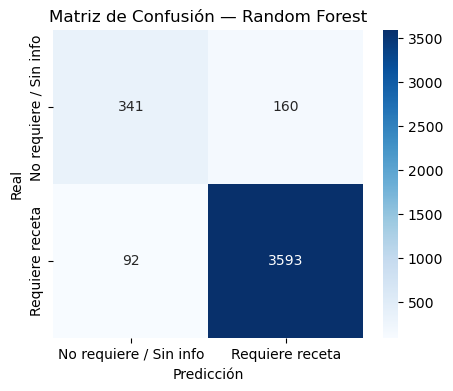

In [45]:
# ======================================
# Paso 24: Matriz de confusión
# ======================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No requiere / Sin info", "Requiere receta"],
    yticklabels=["No requiere / Sin info", "Requiere receta"]
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de Confusión — {mejor_nombre}")
plt.show()


In [46]:
# ======================================
# Paso 25: Reporte de clasificación
# ======================================

print(f"Reporte de Clasificación — {mejor_nombre}\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No requiere / Sin info", "Requiere receta"]
))

Reporte de Clasificación — Random Forest

                        precision    recall  f1-score   support

No requiere / Sin info       0.79      0.68      0.73       501
       Requiere receta       0.96      0.98      0.97      3685

              accuracy                           0.94      4186
             macro avg       0.87      0.83      0.85      4186
          weighted avg       0.94      0.94      0.94      4186



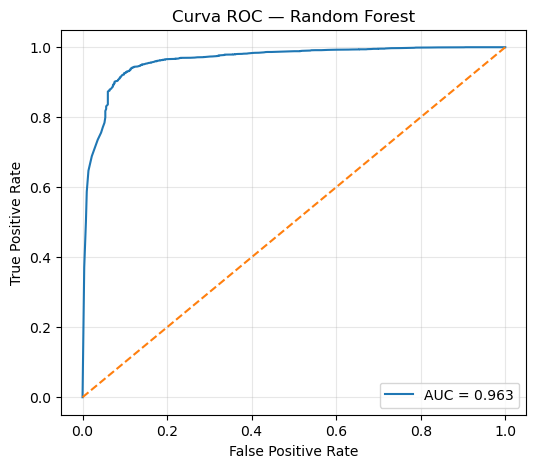

In [47]:
# ======================================
# Paso 26: Curva ROC y AUC
# ======================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Curva ROC — {mejor_nombre}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


 ## 6. Implementación (Generación del archivo .pkl)

En esta fase guardamos el **modelo final** y el **preprocesador** ya entrenados, para poder utilizarlos posteriormente en un entorno de despliegue.

In [48]:
# ======================================
# Paso 27: Guardar modelo final y preprocesador (.pkl)
# ======================================

import joblib
import os

# Crear carpeta "model" si no existe
os.makedirs("model", exist_ok=True)

# Guardar el modelo elegido (mejor_modelo) y el preprocesador
joblib.dump(mejor_modelo, "model/model_final.pkl")
joblib.dump(preprocessor, "model/preprocessor.pkl")

# Guardar también el nombre del modelo para referencia futura
with open("model/model_name.txt", "w") as f:
    f.write(mejor_nombre)

print("\n==============================")
print(" Archivos guardados con éxito ")
print("==============================")
print("→ model/model_final.pkl")
print("→ model/preprocessor.pkl")
print("→ model/model_name.txt")
print("\nEl modelo está listo para usarse en un entorno de despliegue.")


 Archivos guardados con éxito 
→ model/model_final.pkl
→ model/preprocessor.pkl
→ model/model_name.txt

El modelo está listo para usarse en un entorno de despliegue.


In [51]:
plt.savefig("confusion_matrix.png", dpi=1000)
plt.savefig("roc_curve.png", dpi=1000)
plt.savefig("classification_report.png", dpi=1000)

<Figure size 640x480 with 0 Axes>